In [1]:
import pandas as pd 
import numpy as np
from sklearn.linear_model import LinearRegression, SGDRegressor
import matplotlib.pyplot as plt
from tensorflow import keras

In [2]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()

X = housing.data
y = housing.data

print(X, y)

[[   8.3252       41.            6.98412698 ...    2.55555556
    37.88       -122.23      ]
 [   8.3014       21.            6.23813708 ...    2.10984183
    37.86       -122.22      ]
 [   7.2574       52.            8.28813559 ...    2.80225989
    37.85       -122.24      ]
 ...
 [   1.7          17.            5.20554273 ...    2.3256351
    39.43       -121.22      ]
 [   1.8672       18.            5.32951289 ...    2.12320917
    39.43       -121.32      ]
 [   2.3886       16.            5.25471698 ...    2.61698113
    39.37       -121.24      ]] [[   8.3252       41.            6.98412698 ...    2.55555556
    37.88       -122.23      ]
 [   8.3014       21.            6.23813708 ...    2.10984183
    37.86       -122.22      ]
 [   7.2574       52.            8.28813559 ...    2.80225989
    37.85       -122.24      ]
 ...
 [   1.7          17.            5.20554273 ...    2.3256351
    39.43       -121.22      ]
 [   1.8672       18.            5.32951289 ...    2.12320917

## Aufgabe 1

In [3]:
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['Target'] = pd.Series(housing.target)
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


##### Statistische Merkmale

In [4]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


##### Finde alle fehlenden Werte in dem Datensatz

In [5]:
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Target        0
dtype: int64

##### Reduziere den Datensatz auf bestimmte Spalten und konkatiniere sie in einem neue DataFrame

In [6]:
X = df[["HouseAge", "AveRooms" ,"AveBedrms"]]
Y = df[["Target"]]

df_combined = pd.concat([X, Y])
df_combined

,HouseAge,AveRooms,AveBedrms,Target
0,41.0,6.984127,1.023810,NaN
1,21.0,6.238137,0.971880,NaN
2,52.0,8.288136,1.073446,NaN
3,52.0,5.817352,1.073059,NaN
4,52.0,6.281853,1.081081,NaN
...,...,...,...,...
20635,NaN,NaN,NaN,0.781
20636,NaN,NaN,NaN,0.771
20637,NaN,NaN,NaN,0.923
20638,NaN,NaN,NaN,0.847


## Aufgabe 2

##### Führen Sie eine lineare Regression für die Zielgröße housing.target auf Basis aller Merkmale housing.data durch. Überprüfen Sie die Qualität dieses Modells mit einem Testdatensatz.

In [7]:
X = df.iloc[:20639, :8]
y = df.iloc[:20639, 8:]
print(X.shape,Y.shape)

X_test = df.iloc[20639:, :8]
Y_test = df.iloc[20639:, 8:]
print(X_test.shape,Y_test.shape)

(20639, 8) (20640, 1)
(1, 8) (1, 1)


In [8]:
X = housing.data
y = housing.target

print(X.shape,Y.shape)


(20640, 8) (20640, 1)


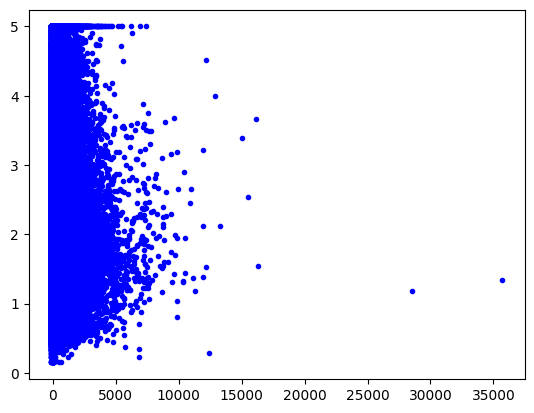

In [9]:
plt.plot(X, Y, "b.")
plt.show()

In [22]:
linear_regression = LinearRegression()
linear_regression.fit(X,Y)

# Ergebnisse:
print("Intercept:", linear_regression.intercept_)
print("Koeffizienten:", linear_regression.coef_)

Intercept: [-36.94192021]
Koeffizienten: [[ 4.36693293e-01  9.43577803e-03 -1.07322041e-01  6.45065694e-01
  -3.97638942e-06 -3.78654265e-03 -4.21314378e-01 -4.34513755e-01]]


In [24]:
y_predicted = linear_regression.predict(X_test)
y_actual = Y_test.values.item()
diff = abs(y_predicted-y_actual)

print("Predicted was:", y_predicted, "and Actual was: ", y_actual, "with a difference of:", diff)

Predicted was: [[0.51580363]] and Actual was:  0.894 with a difference of: [[0.37819637]]


c:\Users\Anton\Documents\HfT\S5\02 - Data Science (Gilg)\Programming\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


In [12]:
linear_regression.score(X,Y)

0.606232685199805

#### SGD (Stochastic Gradient Regression) Regression

In [13]:
sgd_regression = SGDRegressor()

sgd_regression.fit(X,Y)

sgd_regression.intercept_
sgd_regression.coef_

c:\Users\Anton\Documents\HfT\S5\02 - Data Science (Gilg)\Programming\.venv\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


array([ 2.22106862e+11,  1.16015826e+09, -3.55355258e+11, -2.32187446e+11,
        2.50633909e+11, -1.62806856e+11,  8.93206562e+10,  2.00212341e+11])

In [14]:
sgd_regression.score(X,Y)

-1.4463050793490952e+29

In [36]:
y_pred = sgd_regression.predict(X_test)
y_actl = Y_test.values.item()
diff = abs(y_pred - y_actl)

print(f"Predicted was: {y_pred} and Actual was: {y_actl} with a difference of: {diff}")

Predicted was: [3.24854627e+14] and Actual was: 0.894 with a difference of: [3.24854627e+14]


c:\Users\Anton\Documents\HfT\S5\02 - Data Science (Gilg)\Programming\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but SGDRegressor was fitted without feature names
  warnings.warn(


## Aufgabe 3

In [52]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split

X = housing.data
y = housing.target

# Datensatz aufteilen
#X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=2/3, test_size=1/3, random_state=42)

poly_features = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly_features.fit_transform(X)

In [53]:
# Lineare Regression auf erweiterten Trainingsdaten
poly_reg = LinearRegression()
poly_reg.fit(X_poly, y)
poly_reg.score(X_poly, y)

#print(poly_reg.intercept_, poly_reg.coef_)
#poly_reg.coef_.shape

0.7286583859179065

Normalerweise erwarten wir eine Ausgabe wie "(array([1.78]), array([[0.93, 0.56]]))" bei der wir sagen: 
θ_0*X^2 + θ_1*X^1 + θ_0 (Quadratische Funktion), dabei ist 
- Theta[0] ist ​1.78
- 0.93 = X^2
- 0.56 = X

Und die θs werden angepasst, `ABER` das ganze funktioniert nur bei 2 Features bei n-Features haben wir andere Dimensionen z.B. 8 bei haben wir 44 Features (Siehen Skript: Gradientenverfahren für Erklärung)

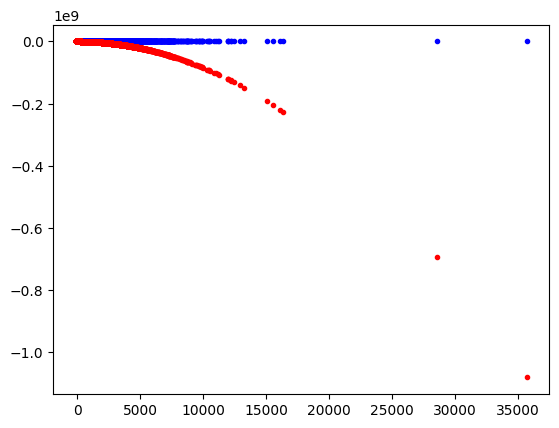

In [ ]:
theta_poly = np.append(poly_reg.intercept_, poly_reg.coef_)
y_poly = theta_poly[2]*(X**2) + theta_poly[1]*X + theta_poly[0]

plt.plot(X, y, "b.")
plt.plot(X, y_poly, "r.")
plt.show()

####  Aufgabe 4

In [101]:
from sklearn.datasets import load_wine
wine = load_wine()
X, y = load_wine(as_frame= True, return_X_y=True)

# a) Berechnen Sie eine Korrelationsmatrix aus allen zu untersuchenden Größen.
X.corr()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
alcohol,1.000000,0.094397,0.211545,-0.310235,0.270798,0.289101,0.236815,-0.155929,0.136698,0.546364,-0.071747,0.072343,0.643720
malic_acid,0.094397,1.000000,0.164045,0.288500,-0.054575,-0.335167,-0.411007,0.292977,-0.220746,0.248985,-0.561296,-0.368710,-0.192011
ash,0.211545,0.164045,1.000000,0.443367,0.286587,0.128980,0.115077,0.186230,0.009652,0.258887,-0.074667,0.003911,0.223626
alcalinity_of_ash,-0.310235,0.288500,0.443367,1.000000,-0.083333,-0.321113,-0.351370,0.361922,-0.197327,0.018732,-0.273955,-0.276769,-0.440597
magnesium,0.270798,-0.054575,0.286587,-0.083333,1.000000,0.214401,0.195784,-0.256294,0.236441,0.199950,0.055398,0.066004,0.393351
total_phenols,0.289101,-0.335167,0.128980,-0.321113,0.214401,1.000000,0.864564,-0.449935,0.612413,-0.055136,0.433681,0.699949,0.498115
flavanoids,0.236815,-0.411007,0.115077,-0.351370,0.195784,0.864564,1.000000,-0.537900,0.652692,-0.172379,0.543479,0.787194,0.494193
nonflavanoid_phenols,-0.155929,0.292977,0.186230,0.361922,-0.256294,-0.449935,-0.537900,1.000000,-0.365845,0.139057,-0.262640,-0.503270,-0.311385
proanthocyanins,0.136698,-0.220746,0.009652,-0.197327,0.236441,0.612413,0.652692,-0.365845,1.000000,-0.025250,0.295544,0.519067,0.330417
color_intensity,0.546364,0.248985,0.258887,0.018732,0.199950,-0.055136,-0.172379,0.139057,-0.025250,1.000000,-0.521813,-0.428815,0.316100


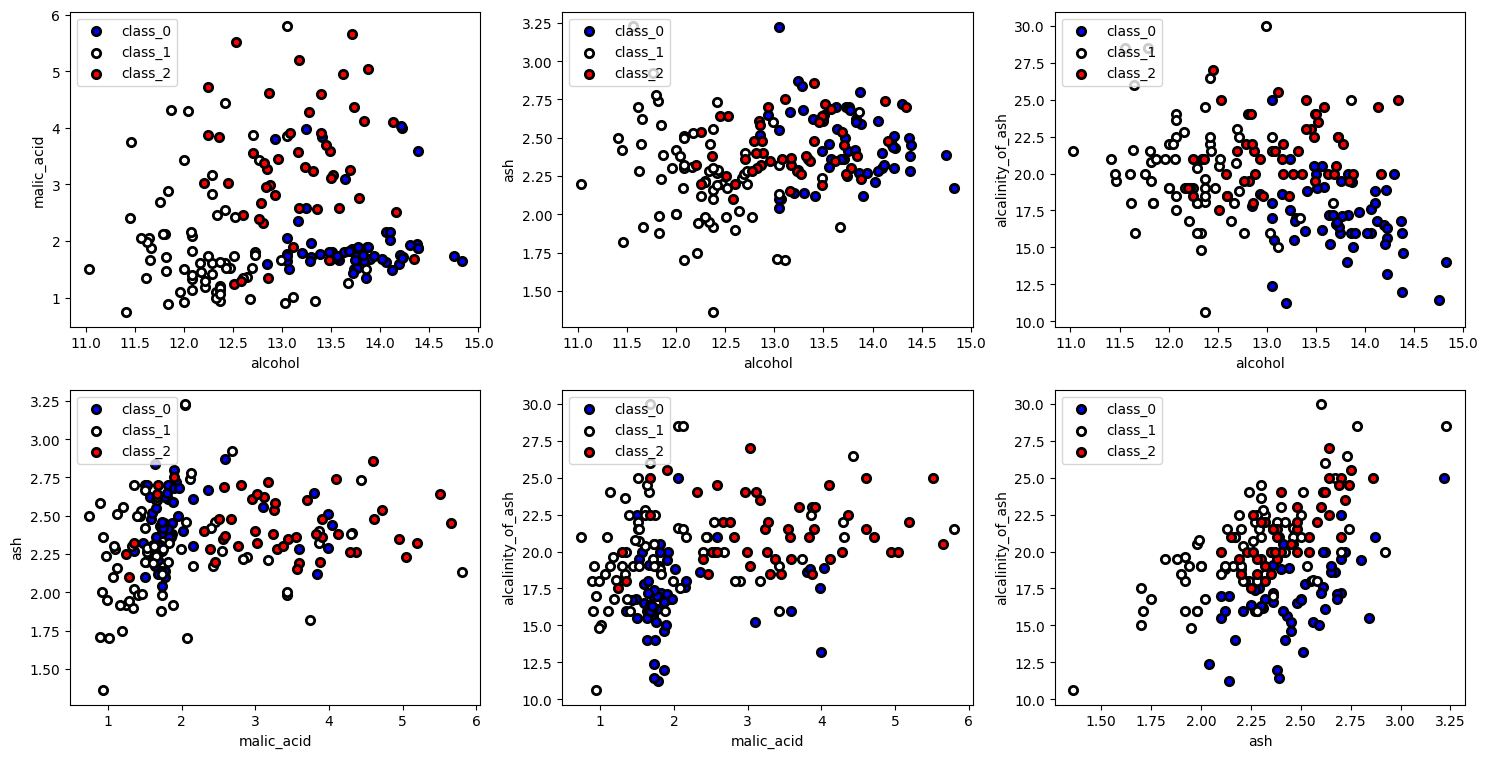

In [100]:
# b) Stellen Sie je zwei der zu untersuchenden Größen in einem Scatterplot da und färben Sie die Punkte nach ihrer Klassenzugehörigkeit ein.

X_data = X.values
y_data = y.values

n_classes = 3
colors = 'bwr'
CMAP = colors # Farbpalette
plot_step = 0.01

fig = plt.figure(1, figsize=(18, 9))

# Berücksichtigung von paarweisen Korrelationen 
for pairidx, pair in enumerate([[0, 1], [0, 2], [0, 3], [1, 2], [1, 3], [2, 3]]):
    X = X_data[:, pair]

    # Plotten jedes einzelnen Subplots
    plt.subplot(2, 3, pairidx + 1)

    # Labeln des Subplots
    plt.xlabel(wine.feature_names[pair[0]])
    plt.ylabel(wine.feature_names[pair[1]]) 

    # Pltten der ausgewerteten Datenpunkte
    for i, color in zip(range(n_classes), colors):
        idx = np.where(y_data == i)
        plt.scatter(X[idx, 0], X[idx, 1], c=color, edgecolor="black", lw=2, label=wine.target_names[i])
        
    plt.axis("tight")
    plt.legend(loc="upper left")

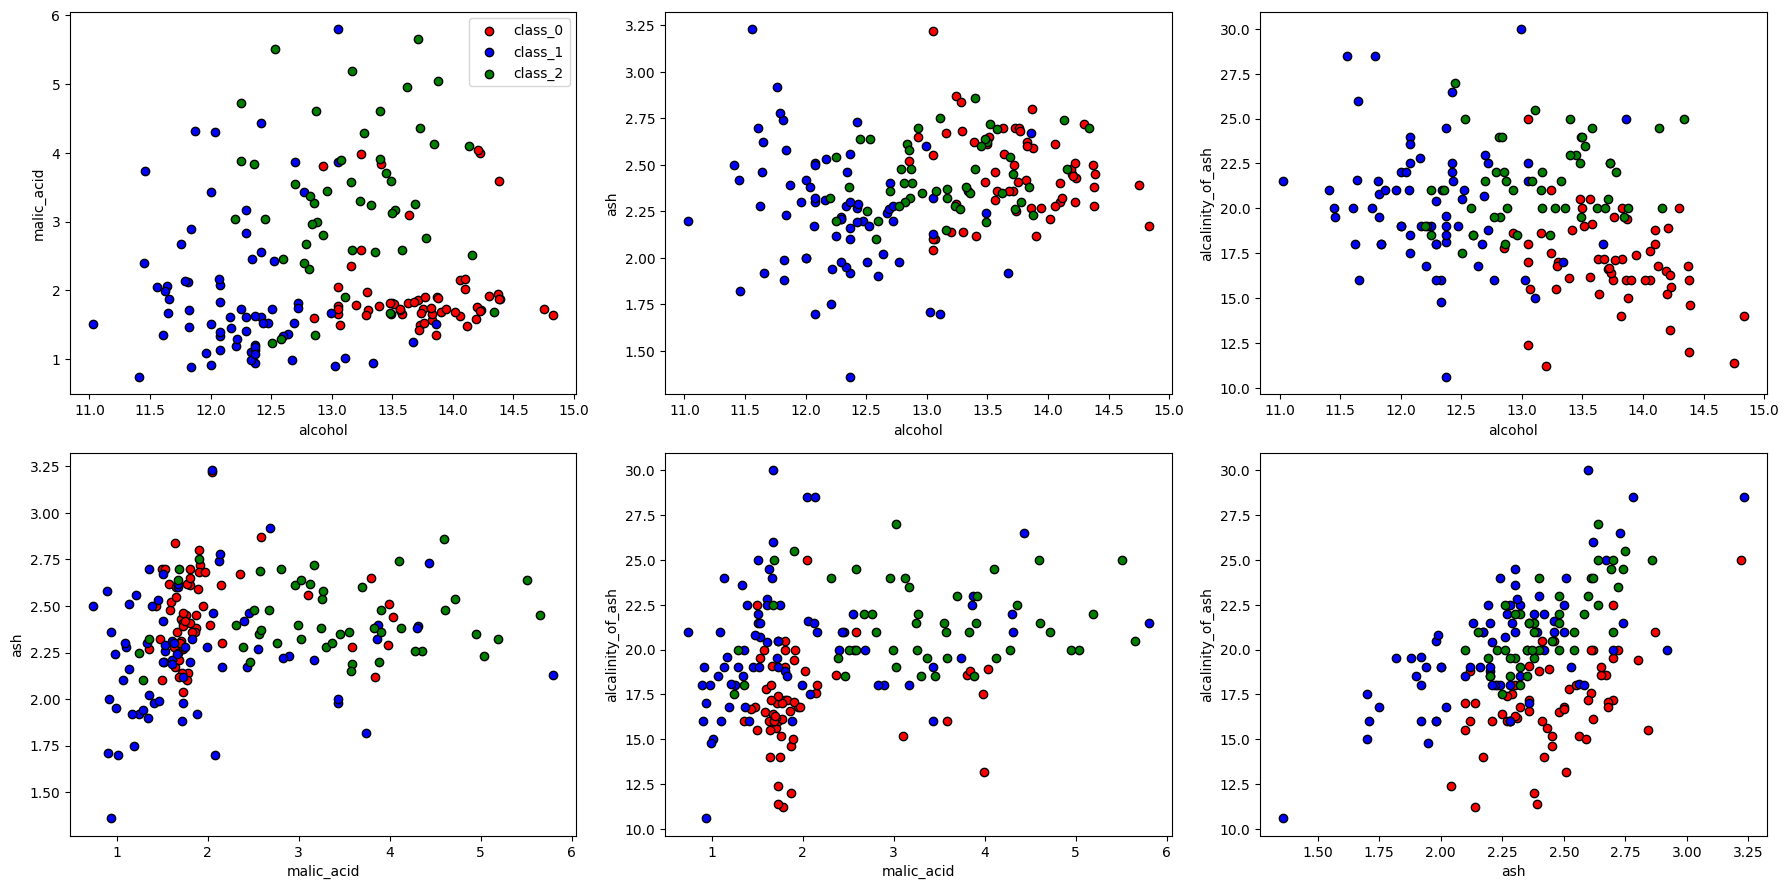

In [102]:
X_data = X.values 
y_data = y.values

n_classes = 4
colors = ['red', 'blue', 'green'] 

fig = plt.figure(1, figsize=(18, 9))

pairs = [[0, 1], [0, 2], [0, 3], [1, 2], [1, 3], [2, 3]]

for pairidx, pair in enumerate(pairs):
    
    # Jetzt arbeiten wir nur noch mit Arrays -> Das funktioniert immer
    X_pair = X_data[:, pair]
    
    plt.subplot(2, 3, pairidx + 1)

    plt.xlabel(wine.feature_names[pair[0]])
    plt.ylabel(wine.feature_names[pair[1]])
    
    for i, color in zip(range(n_classes), colors):
        # np.where funktioniert jetzt korrekt, weil y_data ein Array ist
        idx = np.where(y_data == i)
        
        # Plotten funktioniert jetzt, weil X_pair ein Array ist
        plt.scatter(X_pair[idx, 0], X_pair[idx, 1], c=color, 
                    edgecolor="black", lw=1, label=wine.target_names[i])

    plt.axis("tight") # Passt die Achsen automatisch an die Daten an
    
    if pairidx == 0:
        plt.legend(loc="upper right")

plt.tight_layout()
plt.show()

In [89]:
# c) Führen Sie eine logistische Regression durch und zeigen Sie die Aufteilung der Klassen graphisch für verschiede Merkmalskombinationen.

import sklearn.linear_model as lm 

logr = lm.LogisticRegression(max_iter = 100)
logr.fit(X,y)
logr.score(X,y)

c:\Users\Anton\Documents\HfT\S5\02 - Data Science (Gilg)\Programming\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.9662921348314607